In [16]:
import numpy as np
import matplotlib.pyplot as plt
import string
import os
import matplotlib.cm as cm

plt.rcParams.update(
    {
        "font.size": 11,  # base font size (tick labels)
        "axes.labelsize": 13,  # axis labels
        "axes.titlesize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.dpi": 300,
    }
)

import jax.numpy as jnp
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("cpu")[0])

# Import your optimization and plotting utilities
from optimization_core import (
    scaled_spdc_jsa_chirped,
    load_results,
    to_complex,
)

In [17]:
# ---------------------------------------------------------
# 1. Experiment parameters
# ---------------------------------------------------------
# # Sweep parameters
taup = 0.17  # 3.16#
C = 5

# Dispersion parameters
ldelk01 = 0  # Phase mismatch at the central frequencies
tau11 = 0  # Group-velocity matching
# taup1=1 # \beta_P << \beta_F -->\beta_P negligible in comparison to \beta_F
tauf1 = 1  # \beta_F >> \beta_P
T0 = tauf1 / jnp.sqrt(jnp.pi)  # Pump bandwidth
T01 = 0  # Ultrafast pump approximation

# Geometrical parameters
n_res = 30  # Number of points inside the bandwidth of the phase-matching function in the frequency grid nxnxn
d = 3  # Dimensionality of the problem

# Spectral resolution
sigmapm = (
    jnp.sqrt(jnp.pi) / tauf1
)  # Approximate HWHM of the phase-matching function, measured in terms of the sinc's main lobe width
delw = (
    sigmapm / n_res
)  # The spectral resolution is defined such that a minimum of n discrete points are sampled within each frequency vector over the bandwidth of the phase-matching function, regardless of the specific width of the evaluation function.

# Spectral window
domg = (
    4 * sigmapm
)  # We set the half-width of the frequency window wide enough to sample correctly both the jsa and reduced density matrix
omf = jnp.arange(-domg, domg, delw)
n = omf.size
print(
    n
)  # Note: Always check the frequency vector size, because later we are going to build a 3D grid with it, which greatly affects  the memory usage.

# Create N‑dimensional meshgrid
grid = jnp.meshgrid(*([omf] * d), indexing="ij")

240


In [18]:
filename = f"eigen_eval_results_hopdc_chirped_{d}D_20260620_taup_{taup:.2f}_tauf_{tauf1:.2f}_C_{C}.pkl"
df, _, _ = load_results(filename)
f_pen = to_complex(df["optim_lo"])
fun_pen = df["eta"]
taup_value = df["taup"]

In [ ]:
amp = jnp.abs(f_pen)
phase = jnp.angle(f_pen)

amp_np = np.asarray(amp)
phase_np = np.asarray(phase)

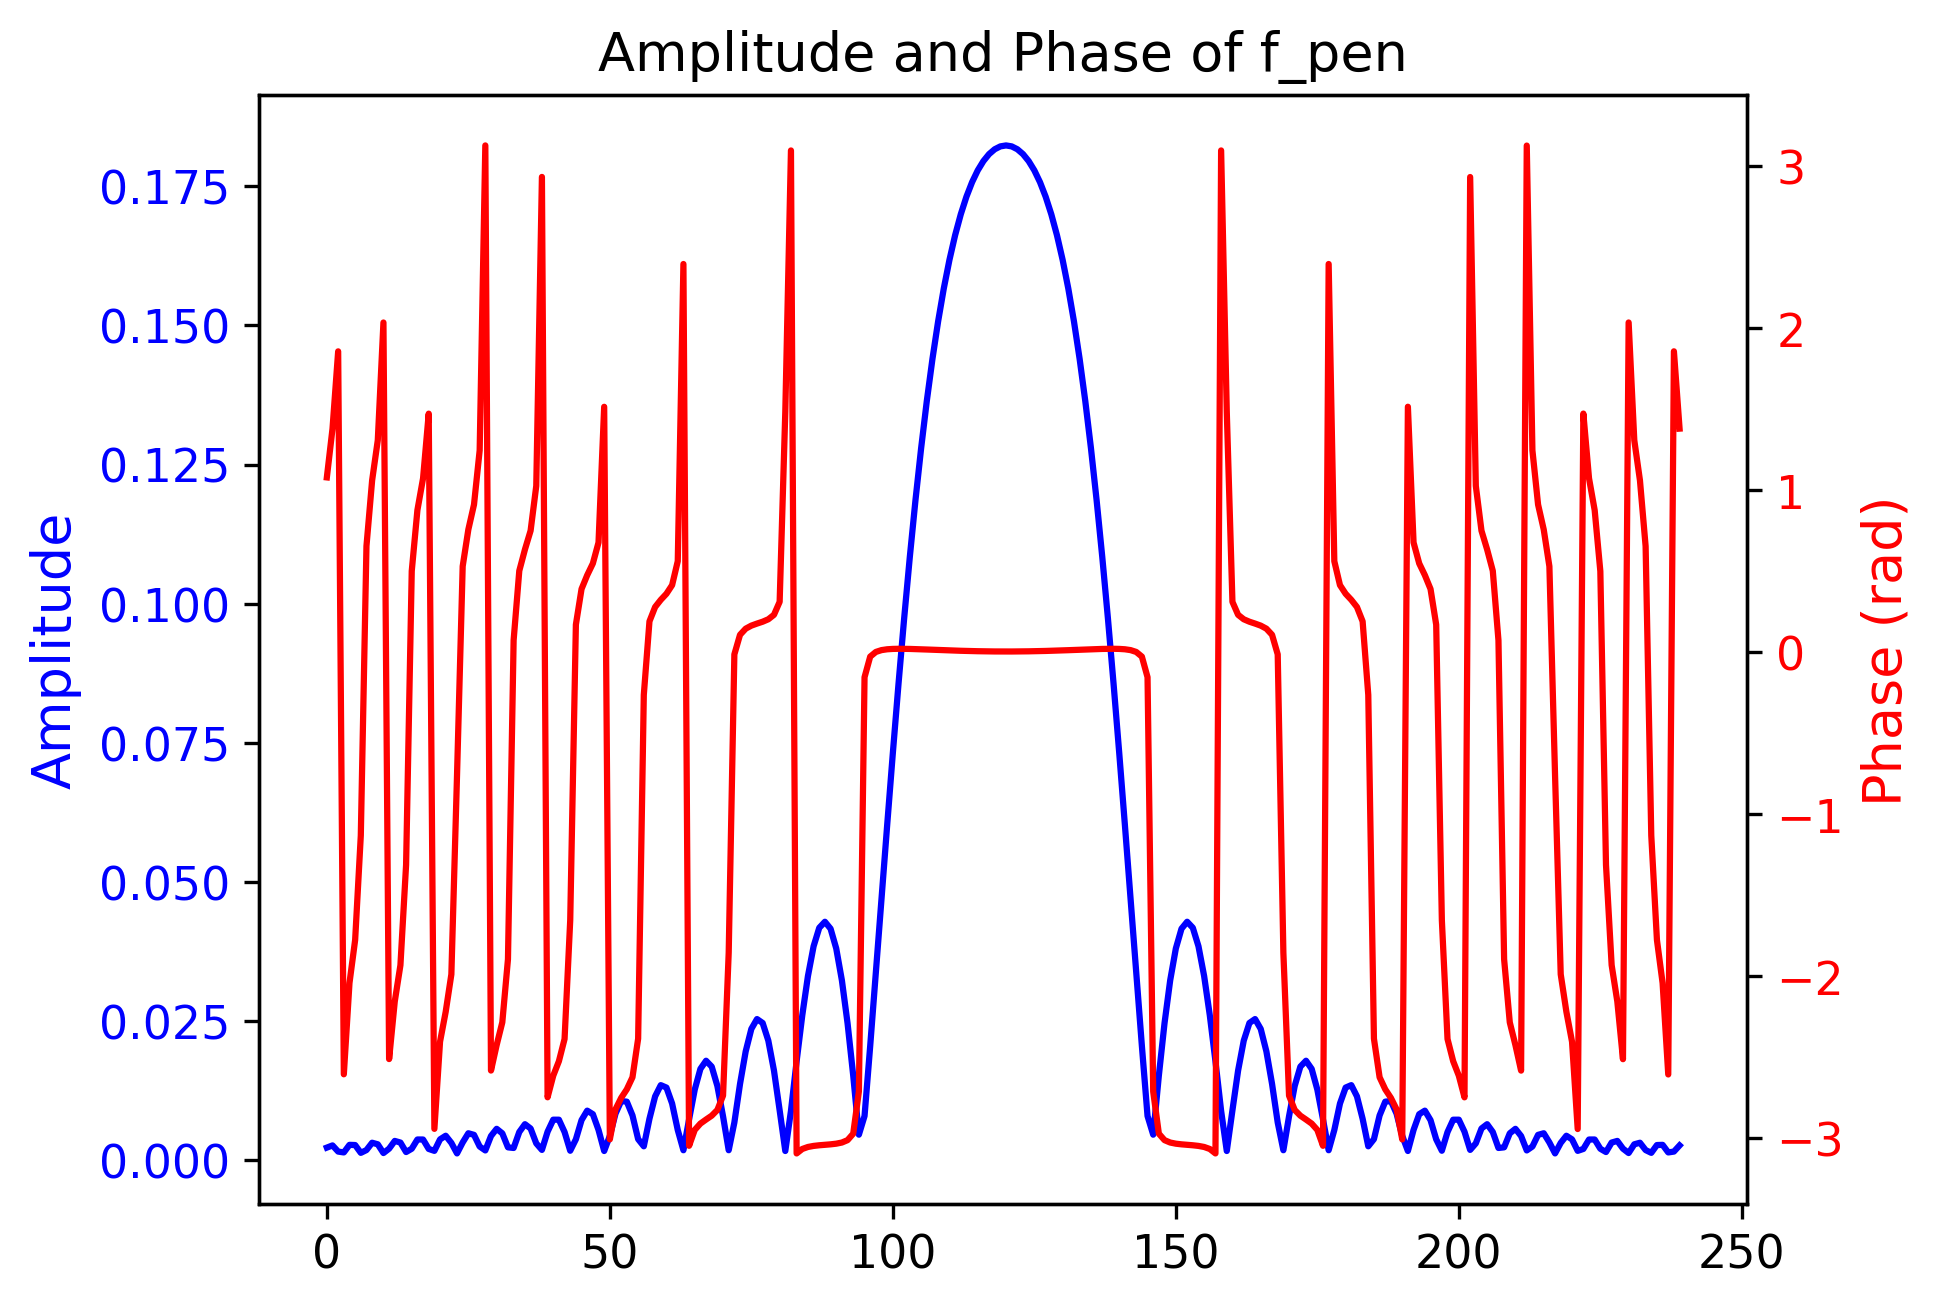

In [20]:
# Compute amplitude and phase
amplitude = np.abs(f_pen)
phase = np.angle(f_pen)

# Plot
fig, ax1 = plt.subplots()

# Amplitude on left axis
ax1.plot(amplitude, color="blue")
ax1.set_ylabel("Amplitude", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Phase on right axis
ax2 = ax1.twinx()
ax2.plot(phase, color="red")
ax2.set_ylabel("Phase (rad)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Amplitude and Phase of f_pen")
plt.show()

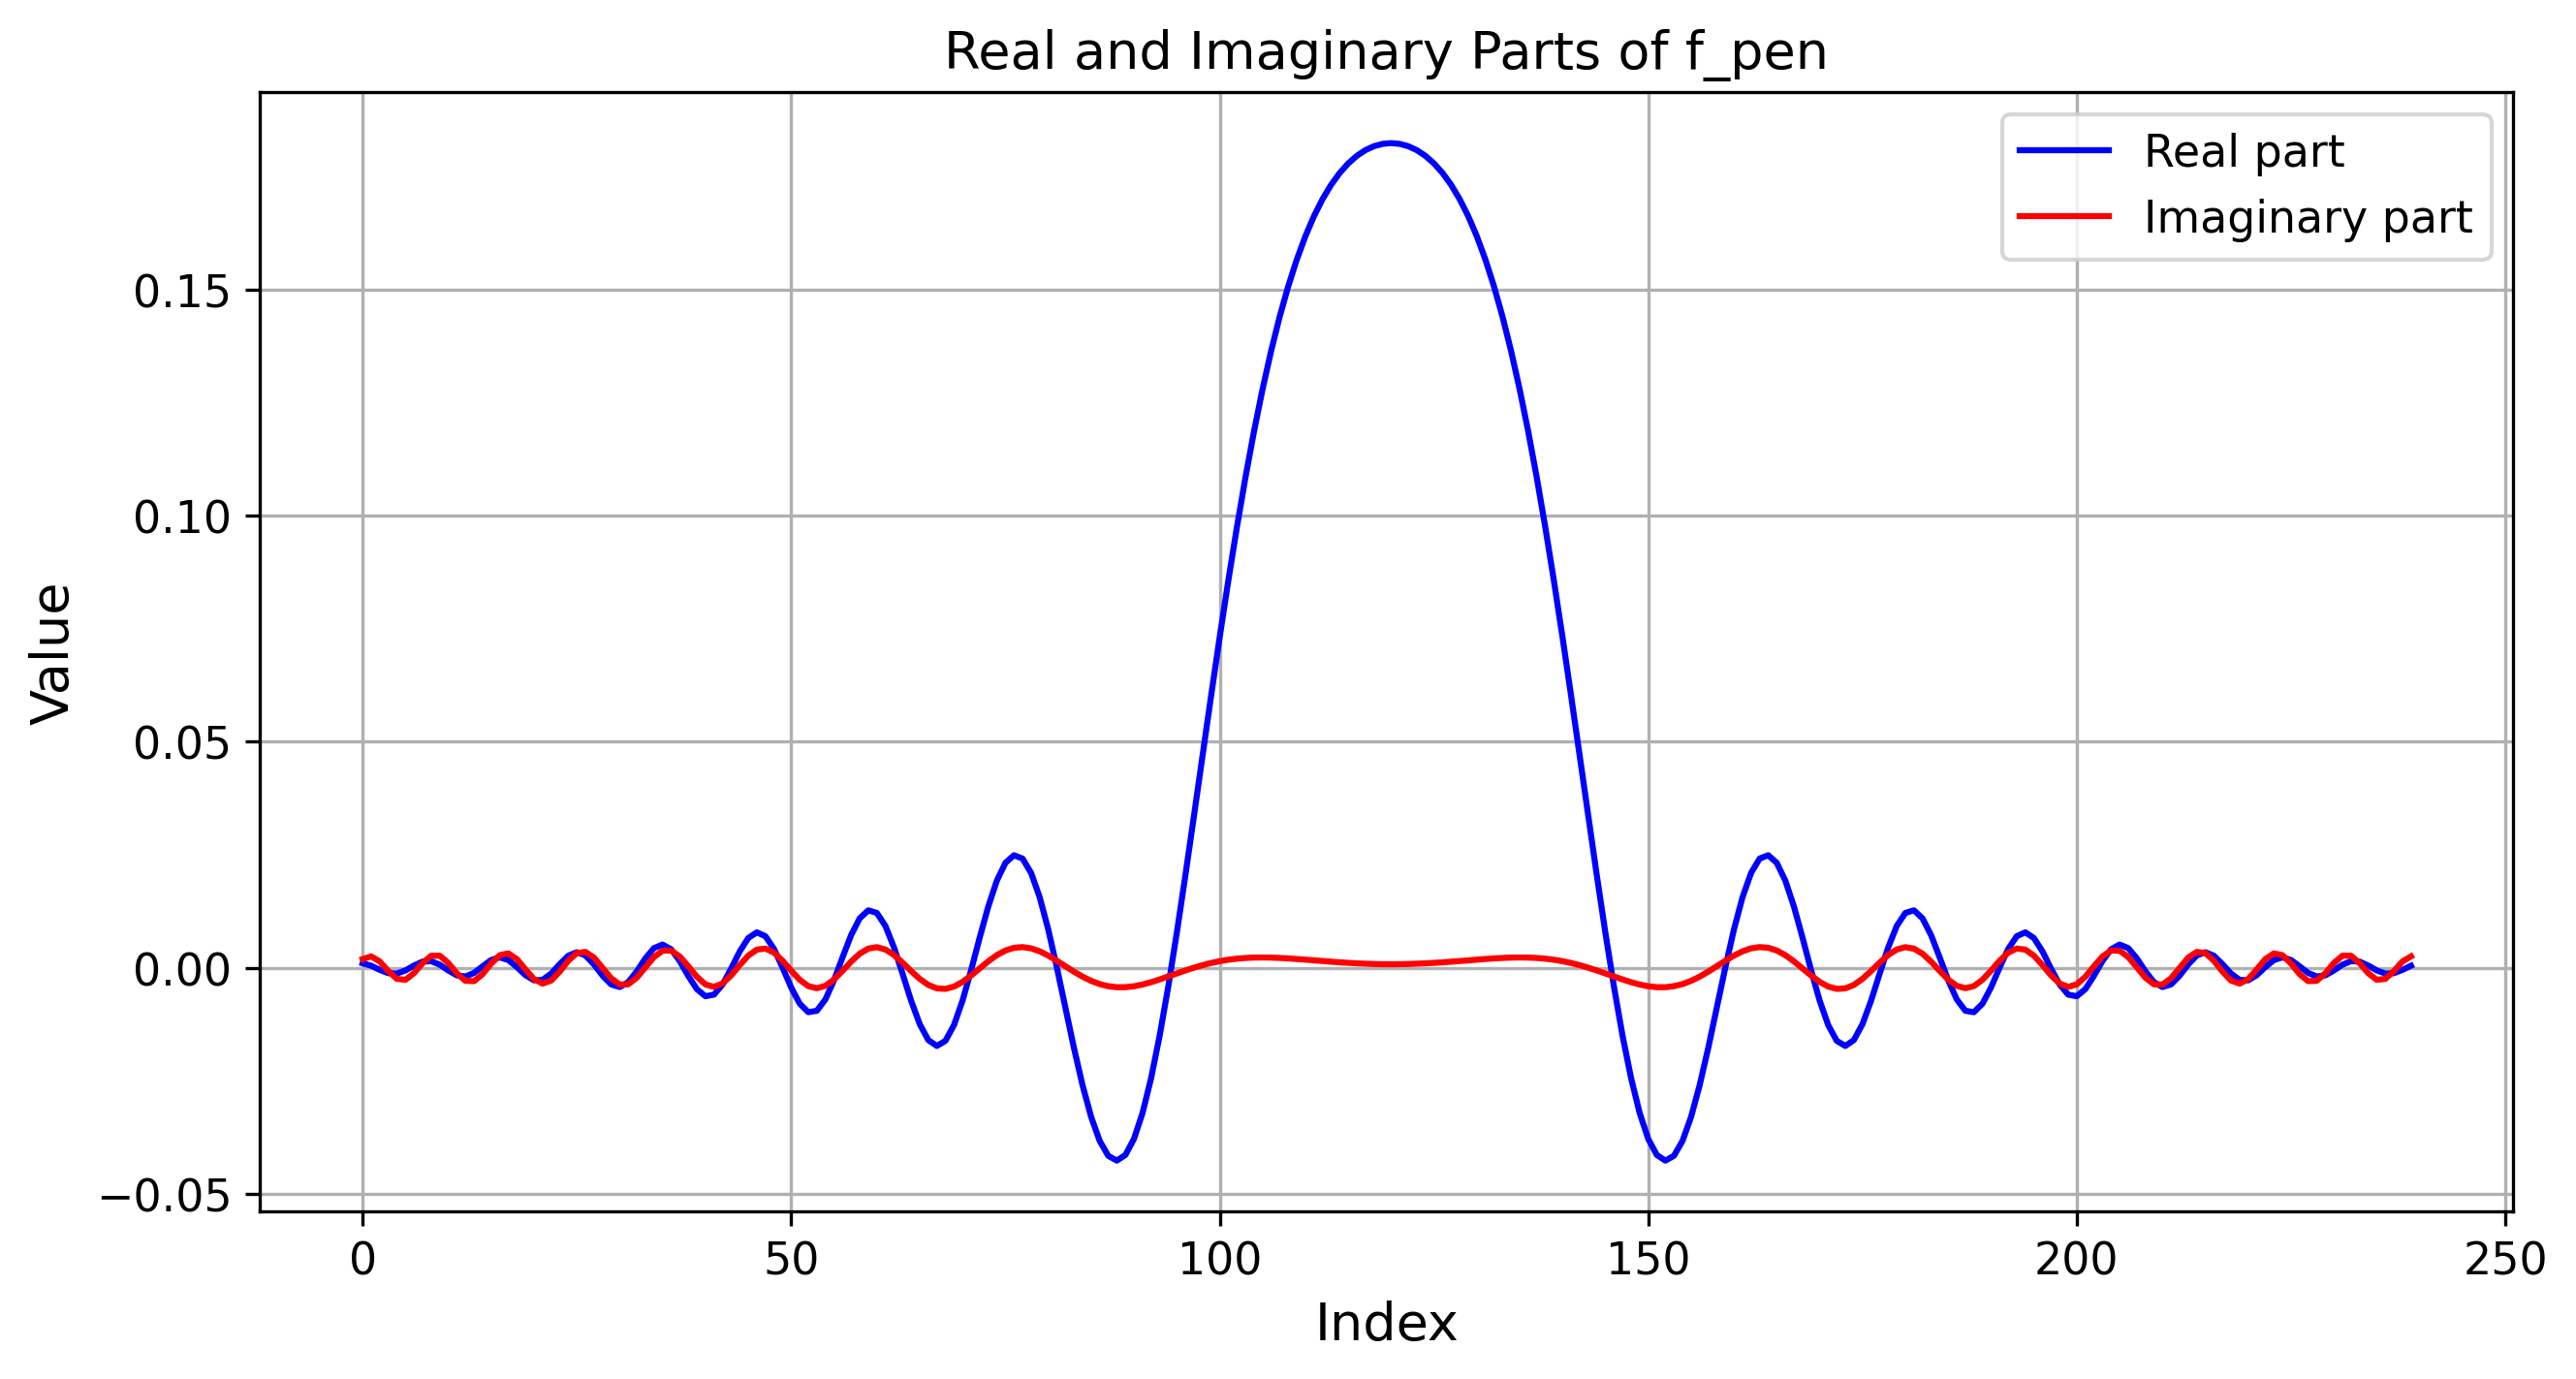

In [21]:
# Extract real and imaginary parts
real_part = np.real(f_pen)
imag_part = np.imag(f_pen)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(real_part / jnp.linalg.norm(f_pen), label="Real part", color="blue")
plt.plot(imag_part / jnp.linalg.norm(f_pen), label="Imaginary part", color="red")
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Real and Imaginary Parts of f_pen")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
jsa = scaled_spdc_jsa_chirped(
    ldelk0=ldelk01, tau1=tau11, taup=taup_value, tauf=tauf1, T0=T0, C=C
)  # Returns a callable function that evaluates the JSA on a point or a grid.
jsa_data = jsa(
    *grid
)  # Evaluate the JSA on the grid. This is the most memory intensive step, as it creates a large tensor of size (n,n,n) in this case. Always check the size of the grid and the resulting tensor to avoid memory issues.
jsa_data /= jnp.linalg.norm(jsa_data)  # Normalize the JSA data.
jsa_flat = jnp.reshape(jsa_data, (n, n ** (d - 1)))
u, s, vt = jax.scipy.linalg.svd(jsa_flat, full_matrices=False)
u_hosvd = u[:, 0] / jnp.linalg.norm(u[:, 0])

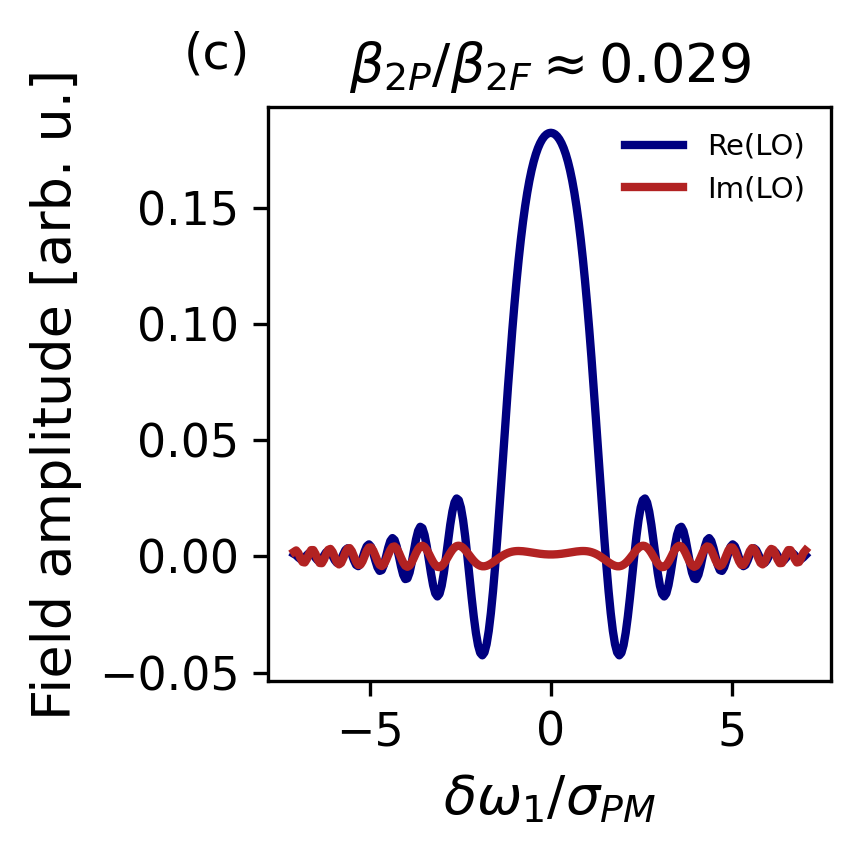

In [23]:
fig, ax = plt.subplots(figsize=(3, 3))

real_part = np.real(f_pen) / np.linalg.norm(f_pen)
imag_part = np.imag(f_pen) / np.linalg.norm(f_pen)


# Optimal LO, bold dashed on top
ax.plot(omf, real_part, color="navy", linewidth=2, label="Re(LO)")
ax.plot(omf, imag_part, color="firebrick", linewidth=2, label="Im(LO)")

ax.set_xlabel(r"$\delta\omega_1/\sigma_{PM}$")
ax.set_ylabel("Field amplitude [arb. u.]")
ax.set_title(r"$\beta_{{2P}}/\beta_{{2F}} \approx %.2g$" % (taup**2 / tauf1**2))
ax.legend(frameon=False, fontsize=7)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

ax.text(-0.15, 1.05, "(c)", transform=ax.transAxes, fontsize=12, va="bottom", ha="left")
plt.tight_layout()
plt.savefig(f"lo_distributions_chirp_003.pdf", dpi=300, bbox_inches="tight")

plt.show()

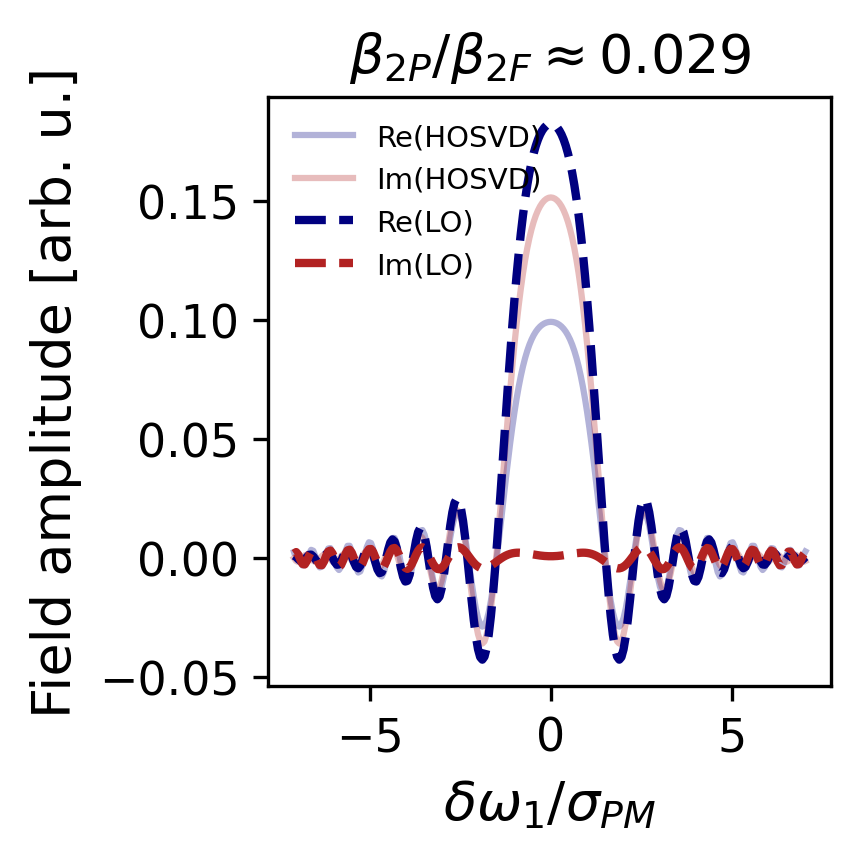

In [24]:
fig, ax = plt.subplots(figsize=(3, 3))

real_part = np.real(f_pen) / np.linalg.norm(f_pen)
imag_part = np.imag(f_pen) / np.linalg.norm(f_pen)
hosvd_real = np.real(u_hosvd) / np.linalg.norm(u_hosvd)
hosvd_imag = np.imag(u_hosvd) / np.linalg.norm(u_hosvd)

# HOSVD in faded background
ax.plot(omf, -hosvd_real, color="navy", alpha=0.3, linewidth=1.5, label="Re(HOSVD)")
ax.plot(omf, hosvd_imag, color="firebrick", alpha=0.3, linewidth=1.5, label="Im(HOSVD)")

# Optimal LO, bold dashed on top
ax.plot(omf, real_part, color="navy", linestyle="--", linewidth=2, label="Re(LO)")
ax.plot(omf, imag_part, color="firebrick", linestyle="--", linewidth=2, label="Im(LO)")

ax.set_xlabel(r"$\delta\omega_1/\sigma_{PM}$")
ax.set_ylabel("Field amplitude [arb. u.]")
ax.set_title(r"$\beta_{{2P}}/\beta_{{2F}} \approx %.2g$" % (taup**2 / tauf1**2))
ax.legend(frameon=False, fontsize=7)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig(f'lo_distributions_chirp_003.pdf', dpi=300, bbox_inches='tight')

plt.show()

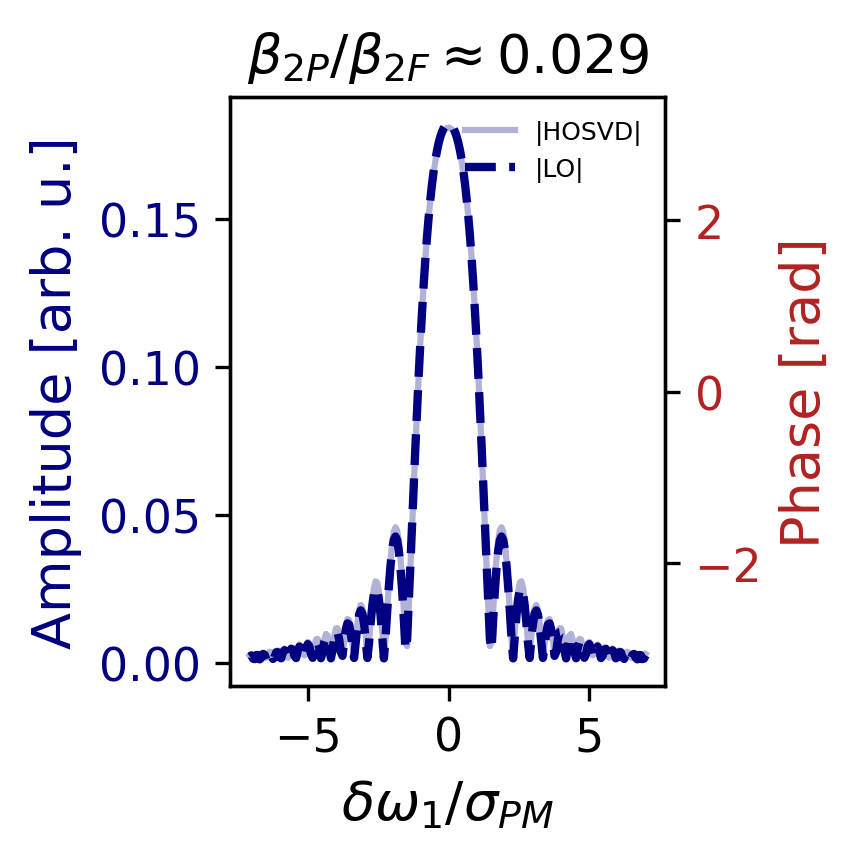

In [25]:
fig, ax1 = plt.subplots(figsize=(3, 3))

# --- Optimal LO ---
amp = np.abs(f_pen) / np.linalg.norm(f_pen)
phase = np.angle(f_pen)

# --- HOSVD comparison ---
amp_h = np.abs(u_hosvd) / np.linalg.norm(u_hosvd)
phase_h = np.angle(u_hosvd)

# --- Amplitude (left axis) ---
ax1.plot(omf, amp_h, color="navy", alpha=0.3, linewidth=1.5, label="|HOSVD|")
ax1.plot(omf, amp, color="navy", linestyle="--", linewidth=2, label="|LO|")
ax1.set_xlabel(r"$\delta\omega_1/\sigma_{PM}$")
ax1.set_ylabel("Amplitude [arb. u.]", color="navy")
ax1.tick_params(axis="y", labelcolor="navy")

# --- Phase (right axis) ---
ax2 = ax1.twinx()
# ax2.plot(omf, phase_h, color='firebrick', alpha=0.3, linewidth=1.5, label='arg(HOSVD)')
# ax2.plot(omf, phase, color='firebrick', linestyle='--', linewidth=2, label='arg(LO)')
ax2.set_ylabel("Phase [rad]", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")
ax2.set_ylim(-np.pi - 0.3, np.pi + 0.3)

ax1.set_title(r"$\beta_{{2P}}/\beta_{{2F}} \approx %.2g$" % (taup**2 / tauf1**2))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2, frameon=False, fontsize=6, loc="upper right"
)

plt.tight_layout()
# plt.savefig('lo_distributions_chirp_003.pdf', dpi=300, bbox_inches='tight')
plt.show()

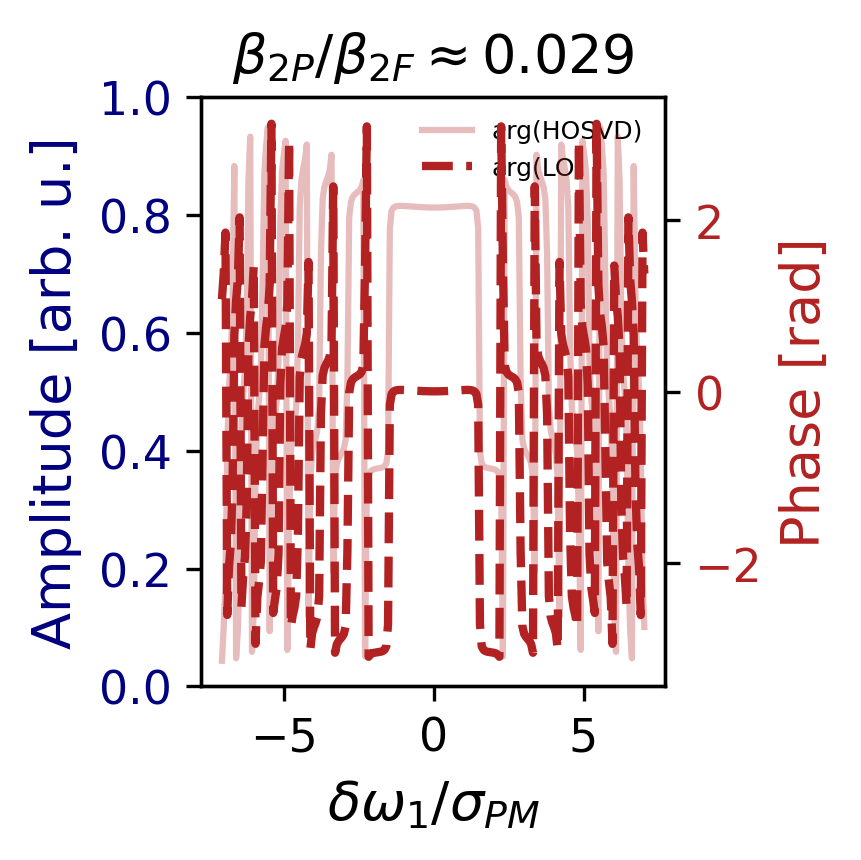

In [26]:
fig, ax1 = plt.subplots(figsize=(3, 3))

# --- Optimal LO ---
amp = np.abs(f_pen) / np.linalg.norm(f_pen)
phase = np.angle(f_pen)

# --- HOSVD comparison ---
amp_h = np.abs(u_hosvd) / np.linalg.norm(u_hosvd)
phase_h = np.angle(u_hosvd)

# --- Amplitude (left axis) ---
# ax1.plot(omf, amp_h, color='navy', alpha=0.3, linewidth=1.5, label='|HOSVD|')
# ax1.plot(omf, amp, color='navy', linestyle='--', linewidth=2, label='|LO|')
ax1.set_xlabel(r"$\delta\omega_1/\sigma_{PM}$")
ax1.set_ylabel("Amplitude [arb. u.]", color="navy")
ax1.tick_params(axis="y", labelcolor="navy")

# --- Phase (right axis) ---
ax2 = ax1.twinx()
ax2.plot(omf, phase_h, color="firebrick", alpha=0.3, linewidth=1.5, label="arg(HOSVD)")
ax2.plot(omf, phase, color="firebrick", linestyle="--", linewidth=2, label="arg(LO)")
ax2.set_ylabel("Phase [rad]", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")
ax2.set_ylim(-np.pi - 0.3, np.pi + 0.3)

ax1.set_title(r"$\beta_{{2P}}/\beta_{{2F}} \approx %.2g$" % (taup**2 / tauf1**2))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2, frameon=False, fontsize=6, loc="upper right"
)

plt.tight_layout()
# plt.savefig('lo_distributions_chirp_003.pdf', dpi=300, bbox_inches='tight')
plt.show()